In [62]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

In [70]:
C1 = '#ffb200'
C2 = '#eb5b00'
C3 = '#d91656'
C4 = '#640d5f'

# https://colorhunt.co/palette/ffb200eb5b00d91656640d5f

COLOR_LIST = [C1,C4,C3,C2]

In [71]:
def read_csv_file(filename: str) -> dict:
    d = {}
    with open(filename, 'r') as rd:
        lines= rd.readlines()
        
    header = lines[0]
    header = header.strip().split(',')[1:]
    for line in lines[1:]:
        x = line.strip().split(',')
        if len(x) == 1:
            continue
        workload = x[0]
        for i in range(len(header)):
            if workload not in d:
                d[workload] = {}
            d[workload][header[i]] = float(x[i+1])
    return d

def get_stats_for_builds(builds: list[str], stat_name: str, reference_mpki: dict, mpki_min=1.5) -> dict:
    out = {}
    
    for b in builds:
        d = read_csv_file(f'../{b}.csv')
        out[b] = { w: stats[stat_name] for (w,stats) in d.items() if reference_mpki[w] >= mpki_min }
    return out

In [72]:
baseline_stats = read_csv_file('../cp_baseline_lru.csv')
reference_mpki = { w: stats['mpki'] for (w,stats) in baseline_stats.items() }

ipc GMEAN of cp_random_writes	5.093
----------------------------
ipc GMEAN of cp_vwq_lru	1.977
ipc GMEAN of cp_balanced_cache_lru	3.183
ipc GMEAN of cp_random_writes	5.093
----------------------------
write_mode_time GMEAN of cp_vwq_lru	2.179
write_mode_time GMEAN of cp_balanced_cache_lru	11.707
write_mode_time GMEAN of cp_random_writes	15.085
----------------------------
aat GMEAN of cp_vwq_lru	2.028
aat GMEAN of cp_balanced_cache_lru	2.547
aat GMEAN of cp_random_writes	5.483
----------------------------
ipc GMEAN of cp_baseline_drrip	0.898
ipc GMEAN of cp_balanced_cache_srrip	2.272
ipc GMEAN of cp_balanced_cache_drrip	3.277
----------------------------


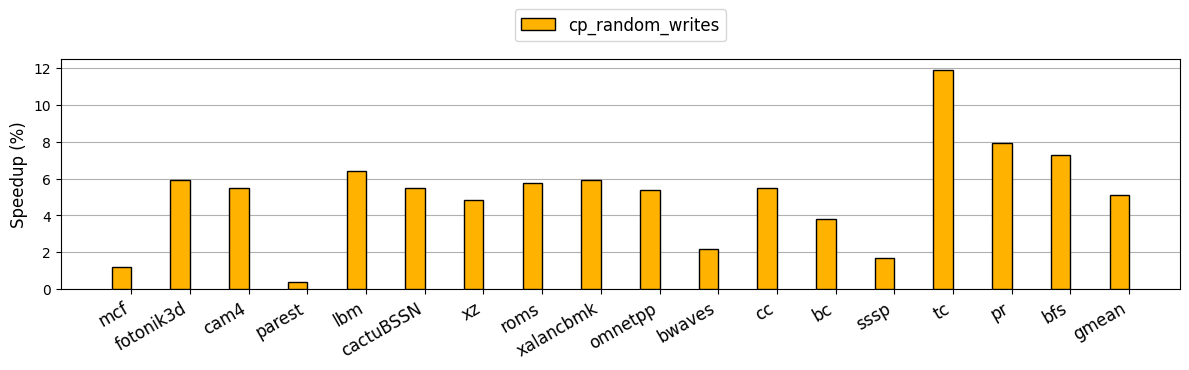

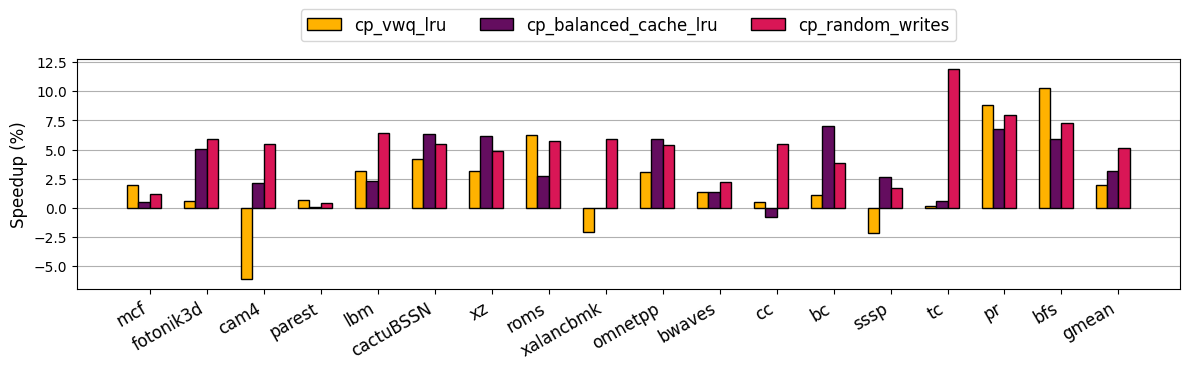

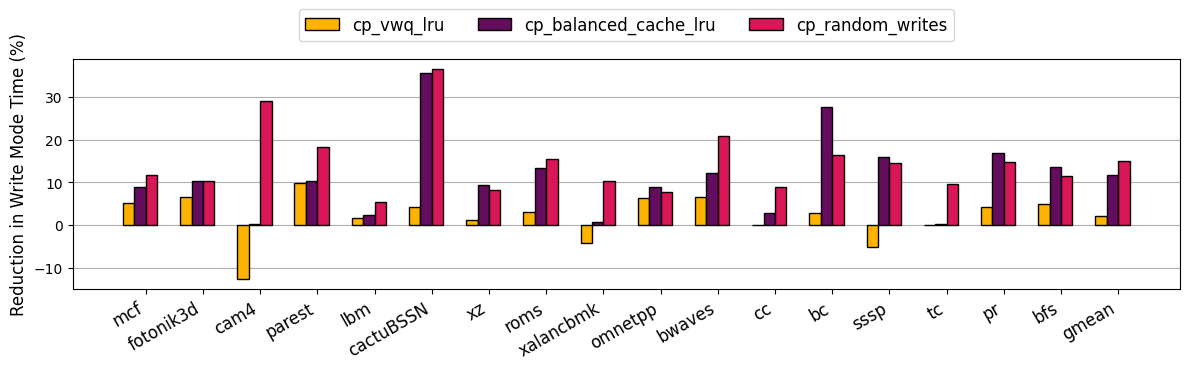

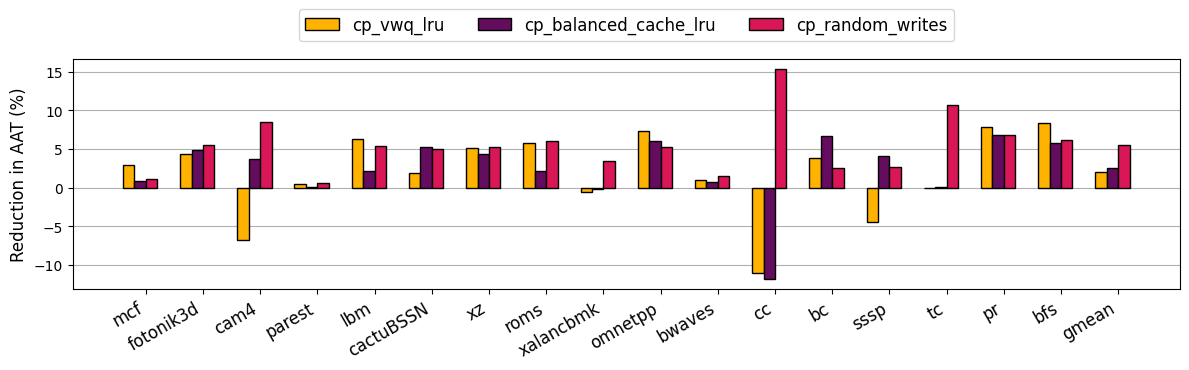

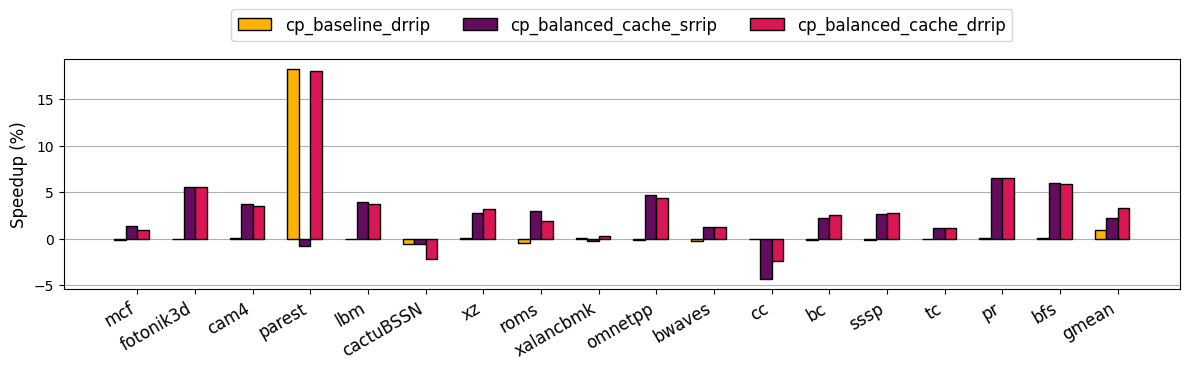

In [88]:
def plot_relative_stat(output_file, builds: list[str], stat_name: str, y_label: str, negate=False, percentage=False):
    stats = get_stats_for_builds(builds, stat_name, reference_mpki=reference_mpki)

    fig, ax = plt.subplots()
    fig.set_size_inches(12.0, 4.0)

    # Plot stats for each build:
    baseline_ipc_list = stats[builds[0]]
    width = 1.0 / (len(builds)+1)
    off = 0

    gmean_list = []
    
    for (i, (b, ipc_list)) in enumerate(stats.items()):
        X = np.arange(len(ipc_list)+1)
        
        # Skip the baseline, but setup the axes of the graph:
        if i == 0:
            workloads = list(ipc_list.keys())
            workloads.append('gmean')
            ax.set_ylabel(y_label, fontsize=12)    
            ax.set_xticks(X + (len(builds)-1)/2 * width, workloads, rotation=30, ha='right', fontsize=12)
            ax.grid(visible=True, axis='y', zorder=0)
            continue
        
        Y = [ ipc_list[w] / baseline_ipc_list[w] for w in ipc_list ]
        
        Y.append(sp.stats.gmean(Y))
        Y = np.array(Y)
        if percentage:
            Y = (Y-1) * 100
        if negate:
            Y = -Y
        gmean_list.append(Y[-1])
        
        ax.bar(X+off, Y, width, color=COLOR_LIST[i-1], label=b, zorder=3, edgecolor='k')
        off += width
    # Setup anything else that is remaining:
    ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=len(builds), loc='upper center')
    plt.tight_layout()
    plt.savefig(output_file, bbox_inches='tight')

    # Print out gmeans:
    for (i,b) in enumerate(builds[1:]):
        g = gmean_list[i]
        print(f'{stat_name} GMEAN of {b}\t{g:.3f}')
    print('----------------------------')

def plot_speedup(output_file, builds):
    plot_relative_stat(output_file, builds, 'ipc', 'Speedup (%)', percentage=True)

def plot_time_in_write_mode(output_file, builds):
    plot_relative_stat(output_file, builds, 'write_mode_time', 'Reduction in Write Mode Time (%)', negate=True, percentage=True)

def plot_aat(output_file, builds):
    plot_relative_stat(output_file, builds, 'aat', 'Reduction in AAT (%)', percentage=True, negate=True)

grp1 = ['cp_baseline_lru', 'cp_random_writes']
grp2 = ['cp_baseline_lru', 'cp_vwq_lru', 'cp_balanced_cache_lru', 'cp_random_writes']
grp3 = ['cp_baseline_srrip', 'cp_baseline_drrip', 'cp_balanced_cache_srrip', 'cp_balanced_cache_drrip']

plot_speedup('motivation.ipc.pdf', grp1)

plot_speedup('results_lru.ipc.pdf', grp2)
plot_time_in_write_mode('results_lru.wm.pdf', grp2)
plot_aat('results_lru.aat.pdf', grp2)


plot_speedup('results_srrip.ipc.pdf', grp3)